# Palm Tree Detection - RetinaNet (TensorFlow + KerasCV + OpenCV)

Model deteksi objek **RetinaNet** dengan backbone ResNet50 ImageNet.

**Stack:** TensorFlow 2.x, KerasCV 0.9.0, OpenCV

**Alur:** Setup -> Data -> Pipeline -> Train -> Evaluate -> Inference -> Export

Setiap cell berisi kode singkat yang fokus pada 1 tugas. Jalankan berurutan dari atas ke bawah.

## 1. Imports & Constants

Cell ini load semua library dan definisikan konstanta global.

In [1]:
# Install dependency

import os, sys, json, random
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import keras_cv
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns

# -- Constants --
SEED        = 42
IMG_SIZE    = 800
BATCH_SIZE  = 2
BBOX_FORMAT = "xywh"
BGR_PALETTE = [
    (94, 197, 34), (68, 68, 239), (203, 192, 255),
    (243, 150, 33), (0, 255, 255), (255, 191, 0), (180, 105, 255),
]
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
print(f"TF={tf.__version__}  KerasCV={keras_cv.__version__}  CV2={cv2.__version__}")

2026-06-06 14:50:21.269329: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-06 14:50:21.272833: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-06 14:50:21.320964: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-06 14:50:21.320997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-06 14:50:21.321834: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

Using TensorFlow backend


/home/kazu/Programming/OpenSource/model-nyawit/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TF=2.15.0  KerasCV=0.8.2  CV2=4.11.0


## 2. Environment & GPU Setup

Deteksi environment (Kaggle vs Local) dan konfigurasi GPU.

In [6]:
def setup_local_environment():
    """Return (SOURCE_ROOT, WORK_ROOT) khusus untuk environment lokal WSL."""
    # Resolusi path: Mundur satu level (..) dari dalam folder 'notebooks' ke root project
    base_dir = Path("..").resolve()
    
    # Arahkan ke folder datasets tempat folder 'annotations' berada
    src = base_dir / "datasets"
    
    # Arahkan output ke folder working
    wrk = base_dir / "working"
    
    # Validasi untuk memastikan struktur folder benar
    if not (src / "annotations").exists():
        raise FileNotFoundError(
            f"Folder anotasi tidak ditemukan di {src}/annotations. "
            "Pastikan kamu menjalankan notebook ini dari dalam folder 'notebooks'."
        )
        
    return src, wrk

# Inisialisasi Path
SOURCE_ROOT, WORK_ROOT = setup_local_environment()
DATA_ROOT = WORK_ROOT / "dataset"

# Buat folder output secara otomatis jika belum ada agar tidak error saat menyimpan
WORK_ROOT.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices("GPU")
print(f"Environment = Local (WSL)")
print(f"GPU Terdeteksi = {len(gpus)}")
print(f"SOURCE_ROOT = {SOURCE_ROOT}")
print(f"WORK_ROOT   = {WORK_ROOT}")

# Konfigurasi memori GPU
for g in gpus:
    try: 
        tf.config.experimental.set_memory_growth(g, True)
    except RuntimeError as e: 
        print(f"Gagal set memory growth: {e}")

Environment = Local (WSL)
GPU Terdeteksi = 0
SOURCE_ROOT = /home/kazu/Programming/OpenSource/model-nyawit/datasets
WORK_ROOT   = /home/kazu/Programming/OpenSource/model-nyawit/working


## 3. Utility: coco_to_records

Fungsi untuk parse COCO JSON menjadi list of records.

In [8]:
def coco_to_records(coco_path, images_src):
    """Parse COCO JSON -> (records, class_names).
    records[i] = {"image_path", "width", "height", "boxes": [[cls,x,y,w,h], ...]}
    """
    coco = json.loads(Path(coco_path).read_text())
    cats = sorted(coco["categories"], key=lambda c: c["id"])
    id2idx = {c["id"]: i for i, c in enumerate(cats)}
    names = [c["name"] for c in cats]
    by_img = defaultdict(list)
    for ann in coco["annotations"]:
        if ann.get("iscrowd"): continue
        x, y, w, h = ann["bbox"]
        if w <= 0 or h <= 0: continue
        cls = id2idx.get(ann["category_id"])
        if cls is None: continue
        by_img[ann["image_id"]].append([float(cls), float(x), float(y), float(w), float(h)])
    records = []
    for iid, img in {i["id"]: i for i in coco["images"]}.items():
        boxes = by_img.get(iid, [])
        if not boxes: continue
        src = Path(images_src) / img["file_name"]
        if not src.exists(): continue
        records.append({"image_path": str(src), "width": img["width"], "height": img["height"], "boxes": boxes})
    return records, names

## 4. Utility: stratified_split

Split dataset secara stratified berdasarkan kelas dominan per gambar.

In [9]:
def dominant_class(rec):
    """Kelas dominan dalam 1 record (untuk stratified split)."""
    if not rec["boxes"]: return 0
    cls = [int(b[0]) for b in rec["boxes"]]
    return max(set(cls), key=cls.count)

def stratified_split(records, train=0.8, val=0.1, test=0.1):
    """Split records -> {"train": ..., "val": ..., "test": ...}."""
    labels = [dominant_class(r) for r in records]
    ti, tmp = train_test_split(range(len(records)), test_size=val+test, stratify=labels, random_state=SEED)
    tl = [labels[i] for i in tmp]
    vf = val / (val + test)
    vi_rel, te_rel = train_test_split(range(len(tmp)), test_size=1-vf, stratify=tl, random_state=SEED)
    return {
        "train": [records[i] for i in ti],
        "val":   [records[i] for i in [tmp[j] for j in vi_rel]],
        "test":  [records[i] for i in [tmp[j] for j in te_rel]],
    }

## 5. Utility: load_or_build_dataset

Load dari cache atau build + simpan records.json.

In [10]:
def load_or_build_dataset(force=False):
    """Load dari cache atau build + cache records.json."""
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    cache = DATA_ROOT / "records.json"
    if cache.exists() and not force:
        data = json.loads(cache.read_text())
        print(f"[CACHE] train={len(data['train'])} val={len(data['val'])} test={len(data['test'])}")
        return data
    tr, n_tr = coco_to_records(SOURCE_ROOT / "annotations/instances_train2017.json", SOURCE_ROOT / "train2017")
    va, _   = coco_to_records(SOURCE_ROOT / "annotations/instances_val2017.json",   SOURCE_ROOT / "val2017")
    split = stratified_split(tr + va)
    data = {"train": split["train"], "val": split["val"], "test": split["test"], "names": n_tr}
    cache.write_text(json.dumps(data))
    print(f"[BUILD] train={len(data['train'])} val={len(data['val'])} test={len(data['test'])}")
    print(f"  Classes: {n_tr}")
    return data

DATASET = load_or_build_dataset()

[CACHE] train=1803 val=250 test=250


## 6. Utility: Visualization

Fungsi untuk menggambar bounding box dan menampilkan record.

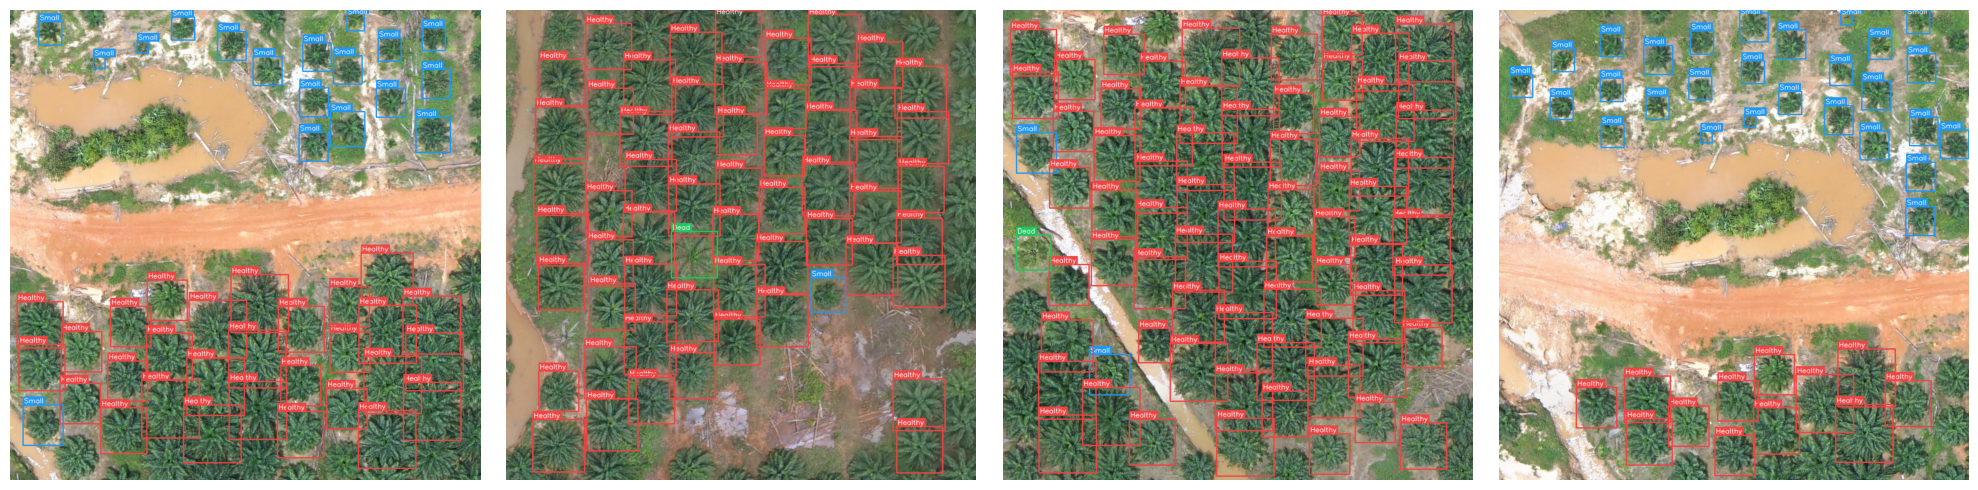

In [11]:
def draw_boxes_cv2(img_bgr, boxes, classes=None):
    """Gambar bounding box di img BGR. Return image baru."""
    classes = classes or DATASET["names"]
    out = img_bgr.copy()
    for box in boxes:
        ci = int(box[0])
        x1, y1 = int(box[1]), int(box[2])
        x2, y2 = int(box[1] + box[3]), int(box[2] + box[4])
        color = BGR_PALETTE[ci % len(BGR_PALETTE)]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        label = classes[ci] if ci < len(classes) else str(ci)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(out, (x1, max(0, y1 - th - 6)), (x1 + tw + 4, y1), color, -1)
        cv2.putText(out, label, (x1 + 2, max(th, y1) - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
    return out

def visualize(records, n=4, save_dir=None):
    """Plot n records dengan bounding box."""
    samples = records[:n]
    if not samples: print("Tidak ada data."); return
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    axes = [axes] if len(samples) == 1 else axes
    for ax, rec in zip(axes, samples):
        img = cv2.imread(rec["image_path"])
        if img is None: ax.set_title("GAGAL"); ax.axis("off"); continue
        ann = draw_boxes_cv2(img, rec["boxes"])
        if save_dir: cv2.imwrite(str(save_dir / Path(rec["image_path"]).name), ann)
        ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        ax.axis("off")
    plt.tight_layout(); plt.show()

PREVIEW_DIR = DATA_ROOT / "preview"
PREVIEW_DIR.mkdir(exist_ok=True)
visualize(DATASET["train"], n=4, save_dir=PREVIEW_DIR)

## 7. Utility: tf.data Pipeline

Fungsi untuk membuat tf.data.Dataset dari records.

In [12]:
def record_generator(records):
    """Yield dict per record untuk tf.data.Dataset.from_generator."""
    for rec in records:
        if rec["boxes"]:
            arr = np.asarray(rec["boxes"], dtype=np.float32)
            yield {"image_path": rec["image_path"], "classes": arr[:, 0].astype(np.int32), "boxes": arr[:, 1:]}
        else:
            yield {"image_path": rec["image_path"], "classes": np.zeros((0,), dtype=np.int32), "boxes": np.zeros((0, 4), dtype=np.float32)}

def _cv2_decode(pb):
    """Decode image via OpenCV untuk tf.numpy_function."""
    p = pb.decode("utf-8") if isinstance(pb, bytes) else pb
    bgr = cv2.imread(p, cv2.IMREAD_COLOR)
    if bgr is None: raise ValueError(f"Gagal baca: {p}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.uint8)

def load_image(sample):
    """Load + decode 1 sample untuk tf.data map."""
    img = tf.numpy_function(_cv2_decode, [sample["image_path"]], tf.uint8)
    img.set_shape([None, None, 3])
    return {"images": tf.cast(img, tf.float32), "bounding_boxes": {"classes": sample["classes"], "boxes": sample["boxes"]}}

## 8. Build Datasets

Panggil make_dataset() untuk train, val, dan test.

In [15]:
def make_dataset(records, training, batch_size=BATCH_SIZE):
    """Buat tf.data.Dataset. Dict format untuk KerasCV."""
    sig = {
        "image_path": tf.TensorSpec((), tf.string),
        "classes": tf.TensorSpec((None,), tf.int32),
        "boxes": tf.TensorSpec((None, 4), tf.float32),
    }
    ds = tf.data.Dataset.from_generator(lambda: record_generator(records), output_signature=sig)
    
    if training:
        ds = ds.shuffle(min(len(records), 1024), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.repeat()  # cegah generator habis mid-epoch
        
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    if training:
        # 1. Layer Spasial (Butuh BBOX_FORMAT karena ikut memodifikasi koordinat objek)
        flip = keras_cv.layers.RandomFlip(mode="horizontal", bounding_box_format=BBOX_FORMAT)
        resize = keras_cv.layers.JitteredResize(
            target_size=(IMG_SIZE, IMG_SIZE), scale_factor=(0.75, 1.3), bounding_box_format=BBOX_FORMAT
        )
        
        # 2. Layer Warna (Pakai bawaan TF agar lebih stabil, faktor 0.2 = range 0.8 s/d 1.2)
        brightness = tf.keras.layers.RandomBrightness(factor=0.2)
        contrast = tf.keras.layers.RandomContrast(factor=0.2)

        def apply_aug(inputs):
            # A. Proses Spasial: Lemparkan seluruh dictionary
            x = flip(inputs)
            x = resize(x)
            
            # B. Proses Warna: Tembak SPESIFIK HANYA ke value "images"-nya saja
            x["images"] = brightness(x["images"])
            x["images"] = contrast(x["images"])
            
            return x # Kembalikan dictionary utuh

        ds = ds.map(apply_aug, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        rs = keras_cv.layers.Resizing(
            IMG_SIZE, IMG_SIZE, pad_to_aspect_ratio=True, bounding_box_format=BBOX_FORMAT
        )
        ds = ds.map(rs, num_parallel_calls=tf.data.AUTOTUNE)
        
    return ds.ragged_batch(batch_size, drop_remainder=training).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(DATASET["train"], training=True)
val_ds   = make_dataset(DATASET["val"],   training=False)
test_ds  = make_dataset(DATASET["test"],  training=False)
print(f"Datasets OK. IMG={IMG_SIZE} BATCH={BATCH_SIZE}")

Datasets OK. IMG=800 BATCH=2


## 9. Model: Build & Compile

Buat model RetinaNet dengan backbone ResNet50 ImageNet.

In [ ]:
ckpt_dir = WORK_ROOT / "runs" / "palm_detection" / "retinanet_v2"
ckpt_dir.mkdir(parents=True, exist_ok=True)
best_w = ckpt_dir / "best.weights.h5"

model = keras_cv.models.RetinaNet.from_preset(
    "resnet50_imagenet", num_classes=len(DATASET["names"]), bounding_box_format=BBOX_FORMAT)
model.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format=BBOX_FORMAT, from_logits=True, iou_threshold=0.5, confidence_threshold=0.05)
print(f"Model created. Classes: {len(DATASET['names'])}")

## 10. LR Schedule: Warmup + CosineDecay

Learning rate schedule dengan linear warmup lalu cosine decay.

In [ ]:
EPOCHS  = 50
LR_INIT = 0.001
WARMUP  = 5  # epochs

SPE = max(1, len(DATASET["train"]) // BATCH_SIZE)
TS  = EPOCHS * SPE
WS  = WARMUP * SPE

class WarmupSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup lalu cosine decay."""
    def __init__(self, ws, base, lr0):
        self.ws, self.base, self.lr0 = ws, base, lr0
    def __call__(self, step):
        warmup_lr = self.lr0 * tf.cast(step, tf.float32) / tf.cast(self.ws, tf.float32)
        return tf.cond(step < self.ws, lambda: warmup_lr, lambda: self.base(step - self.ws))

cosine = tf.keras.optimizers.schedules.CosineDecay(LR_INIT, TS - WS, alpha=1e-6)
opt = tf.keras.optimizers.SGD(
    learning_rate=WarmupSchedule(WS, cosine, LR_INIT),
    momentum=0.9, global_clipnorm=10.0)

model.compile(optimizer=opt, classification_loss="focal", box_loss="smoothl1", jit_compile=False)
print(f"Compiled. SPE={SPE}  warmup={WS}  total={TS}")

## 11. Callbacks

Definisi callbacks untuk training.

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(best_w), save_weights_only=True,
        monitor="val_loss", mode="min", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.CSVLogger(str(ckpt_dir / "training_log.csv")),
    tf.keras.callbacks.TerminateOnNaN(),
    tf.keras.callbacks.TensorBoard(log_dir=str(ckpt_dir / "logs"), histogram_freq=1),
]
print(f"Callbacks: {len(callbacks)}")

## 12. Training

Jalankan training. Otomatis resume dari checkpoint jika tersedia.

In [ ]:
if best_w.exists():
    try:
        model.load_weights(str(best_w))
        print("Resumed dari checkpoint.")
    except Exception as e:
        print(f"Gagal resume: {e}")

history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, steps_per_epoch=SPE, callbacks=callbacks,
)

# Plot loss curve
h = history.history
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(h.get("loss", []), label="train")
if "val_loss" in h: ax.plot(h["val_loss"], label="val")
ax.set(xlabel="Epoch", ylabel="Loss")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ckpt_dir / "loss_curve.png", dpi=120)
plt.show()
print(f"Best weights: {best_w}")

## 13. Evaluation: COCO mAP

Hitung COCO metrics pada test set. Hasil predict disimpan untuk reuse di confusion matrix.

In [ ]:
if best_w.exists():
    model.load_weights(str(best_w))

test_eval = make_dataset(DATASET["test"], training=False, batch_size=1)
MAX_BOXES = 200

coco = keras_cv.metrics.BoxCOCOMetrics(
    bounding_box_format=BBOX_FORMAT, evaluate_freq=10**9)
all_pred, all_gt = [], []
coco.reset_state()

for batch in test_eval:
    yp = model.predict(batch["images"], verbose=0)
    gd = keras_cv.bounding_box.to_dense(batch["bounding_boxes"], max_boxes=MAX_BOXES)
    pd = keras_cv.bounding_box.to_dense(yp, max_boxes=MAX_BOXES)
    coco.update_state(gd, pd)
    all_pred.append({
        "b": np.asarray(yp["boxes"][0]),
        "c": np.asarray(yp["classes"][0]),
        "s": np.asarray(yp["confidence"][0]),
    })
    all_gt.append({
        "b": np.asarray(batch["bounding_boxes"]["boxes"][0]),
        "c": np.asarray(batch["bounding_boxes"]["classes"][0]),
    })

res = coco.result(force=True)
print("\n=== COCO Metrics ===")
for k, v in res.items():
    print(f"  {k:35s}: {float(v):.4f}")
with open(ckpt_dir / "coco_metrics.json", "w") as f:
    json.dump({k: float(v) for k, v in res.items()}, f, indent=2)

## 14. Box-Matched Confusion Matrix

Match prediksi ke ground truth via IoU > 0.5, lalu hitung confusion matrix.

In [ ]:
def iou_xywh(a, b):
    """IoU antara 2 box [x, y, w, h]."""
    x1a, y1a, x2a, y2a = a[0], a[1], a[0] + a[2], a[1] + a[3]
    x1b, y1b, x2b, y2b = b[0], b[1], b[0] + b[2], b[1] + b[3]
    iw = max(0, min(x2a, x2b) - max(x1a, x1b))
    ih = max(0, min(y2a, y2b) - max(y1a, y1b))
    inter = iw * ih
    union = a[2] * a[3] + b[2] * b[3] - inter
    return inter / union if union > 0 else 0.0

CONF_TH  = 0.5
IOU_TH   = 0.5
BG_CLASS = len(DATASET["names"])

y_true_m, y_pred_m = [], []
for p, g in zip(all_pred, all_gt):
    vm = p["s"] >= CONF_TH
    pb, pc, ps = p["b"][vm], p["c"][vm], p["s"][vm]
    gb, gc = g["b"], g["c"]
    matched = [False] * len(gb)
    order = np.argsort(-ps) if len(ps) > 0 else []
    for pi in order:
        best_iou, best_g = 0.0, -1
        for gi in range(len(gb)):
            if matched[gi]: continue
            iv = iou_xywh(pb[pi], gb[gi])
            if iv > best_iou: best_iou, best_g = iv, gi
        if best_iou >= IOU_TH and best_g >= 0:
            matched[best_g] = True
            y_true_m.append(int(gc[best_g]))
            y_pred_m.append(int(pc[pi]))
        else:
            y_true_m.append(BG_CLASS)
            y_pred_m.append(int(pc[pi]))
    for gi in range(len(gb)):
        if not matched[gi]:
            y_true_m.append(int(gc[gi]))
            y_pred_m.append(BG_CLASS)

labels = list(range(BG_CLASS + 1))
names  = DATASET["names"] + ["Background"]
cm = confusion_matrix(y_true_m, y_pred_m, labels=labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names)
plt.title("Box-Matched Confusion Matrix (IoU>0.5, Conf>0.5)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(ckpt_dir / "confusion_matrix.png", dpi=120)
plt.show()

print(classification_report(y_true_m, y_pred_m, labels=labels, target_names=names, zero_division=0))

## 15. Per-Class Analysis

Precision, Recall, F1 per kelas.

In [ ]:
print("\n=== Per-Class Analysis ===")
for i, name in enumerate(DATASET["names"]):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    sup = tp + fn
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    print(f"  {name:12s}: P={p:.3f}  R={r:.3f}  F1={f1:.3f}  N={sup}")

## 16. Inference: detect_and_count

Fungsi untuk deteksi objek dalam 1 gambar.

In [ ]:
OUTPUT_DIR = WORK_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_inference_resizer = keras_cv.layers.Resizing(
    IMG_SIZE, IMG_SIZE, pad_to_aspect_ratio=True, bounding_box_format=BBOX_FORMAT)

def detect_and_count(img_path, model, conf=0.5, save_path=None, show=True):
    """Deteksi objek dalam 1 gambar. Return dict {cls_idx: count}."""
    img = cv2.imread(str(img_path))
    if img is None: raise FileNotFoundError(img_path)
    h0, w0 = img.shape[:2]
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    inp = {
        "images": tf.cast(rgb, tf.float32)[tf.newaxis],
        "bounding_boxes": {
            "classes": tf.zeros((1, 0), tf.int32),
            "boxes": tf.zeros((1, 0, 4), tf.float32),
        },
    }
    inp = _inference_resizer(inp)
    pr = model.predict(inp["images"], verbose=0)
    bx = np.asarray(pr["boxes"][0], dtype=np.float32)
    cl = np.asarray(pr["classes"][0], dtype=np.int32)
    sc = np.asarray(pr["confidence"][0], dtype=np.float32)

    keep = (cl >= 0) & (sc >= conf)
    bx, cl, sc = bx[keep], cl[keep], sc[keep]

    # Reverse-map koordinat ke gambar asli
    scale = min(IMG_SIZE / w0, IMG_SIZE / h0)
    pad_x = (IMG_SIZE - w0 * scale) / 2
    pad_y = (IMG_SIZE - h0 * scale) / 2
    if len(bx) > 0:
        bx[:, 0] = (bx[:, 0] - pad_x) / scale
        bx[:, 1] = (bx[:, 1] - pad_y) / scale
        bx[:, 2] /= scale
        bx[:, 3] /= scale

    # Render
    counts = defaultdict(int)
    for b, c in zip(bx, cl):
        counts[int(c)] += 1
    ann = draw_boxes_cv2(img, [[c, b[0], b[1], b[2], b[3]] for b, c in zip(bx, cl)])

    # Counter overlay
    y0 = 25
    for ci, cnt in sorted(counts.items()):
        name = DATASET["names"][ci] if ci < len(DATASET["names"]) else str(ci)
        cv2.putText(ann, f"{name}:{cnt}", (10, y0),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    BGR_PALETTE[ci % len(BGR_PALETTE)], 2, cv2.LINE_AA)
        y0 += 24

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(save_path), ann)
    if show:
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return dict(counts)

## 17. Run Inference

Jalankan inference pada sampel test.

In [ ]:
print("Inference on test samples...\n")
for i, rec in enumerate(DATASET["test"][:5]):
    out_path = OUTPUT_DIR / f"detected_{i:03d}.jpg"
    counts = detect_and_count(rec["image_path"], model, conf=0.5, save_path=out_path)
    label_counts = {
        DATASET["names"][k] if k < len(DATASET["names"]) else str(k): v
        for k, v in counts.items()
    }
    print(f"  [{i}] {Path(rec['image_path']).name} -> {label_counts}")

## 18. Export Model

Export ke SavedModel, TFLite, dan ONNX.

In [ ]:
exp = ckpt_dir / "exported"
exp.mkdir(parents=True, exist_ok=True)
sm = exp / "saved_model"

if best_w.exists():
    model.load_weights(str(best_w))

# SavedModel
ok = False
try:
    if hasattr(model, "export"):
        model.export(str(sm))
    else:
        model.save(str(sm), save_format="tf")
    ok = sm.exists()
    print(f"SavedModel: {sm}")
except Exception as e:
    print(f"SavedModel gagal: {e}")
    model.save_weights(str(exp / "best.weights.h5"))

# TFLite
try:
    if ok:
        cvt = tf.lite.TFLiteConverter.from_saved_model(str(sm))
        cvt.optimizations = [tf.lite.Optimize.DEFAULT]
        Path(exp / "best.tflite").write_bytes(cvt.convert())
        print(f"TFLite: {exp / 'best.tflite'}")
except Exception as e:
    print(f"TFLite gagal: {e}")

# ONNX
try:
    import tf2onnx  # noqa
    if ok:
        rc = os.system(
            f'python -m tf2onnx.convert --saved-model "{sm}" '
            f'--output "{exp}/best.onnx" --opset 17')
except ImportError:
    print("tf2onnx tidak terinstall.")

print("\nArtifacts:")
for p in sorted(exp.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(exp)}  ({p.stat().st_size / 1024 / 1024:.1f} MB)")